In [1]:
import matplotlib.pyplot as plt

In [2]:
def generate_multigrid_cycle_data(cycle_index: int, num_levels: int):
    """
    Generates (x, y) coordinates for visualizing a multigrid cycle.

    Args:
        cycle_index (int): 1 for V-cycle, 2 for W-cycle, etc.
        num_levels (int): Total number of grid levels (e.g., 3, 4, 5).

    Returns
    -------
        tuple: (x_coords, y_coords) where y represents the grid level
               (finest at the top) and x represents the sequential step.
    """
    if num_levels < 1:
        raise ValueError("Number of levels must be at least 1.")
    if cycle_index < 1:
        raise ValueError("Cycle index must be at least 1 (1=V, 2=W).")

    x_coords = []
    y_coords = []

    def traverse(level, current_step, is_top_level):
        # Record the current position
        x_coords.append(current_step)
        y_coords.append(level)

        # Base case: reached the coarsest level
        if level == 1:
            return current_step

        # Top level executes exactly one full cycle.
        # Coarser levels execute 'cycle_index' times to form the target shape.
        num_calls = 1 if is_top_level else cycle_index

        for _ in range(num_calls):
            # Move down to the coarser grid
            current_step += 1
            current_step = traverse(level - 1, current_step, is_top_level=False)

            # Move back up to the current grid
            current_step += 1
            x_coords.append(current_step)
            y_coords.append(level)

        return current_step

    # Start the recursion at the finest level (num_levels)
    traverse(level=num_levels, current_step=0, is_top_level=True)

    return x_coords, y_coords

In [3]:
import matplotlib
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

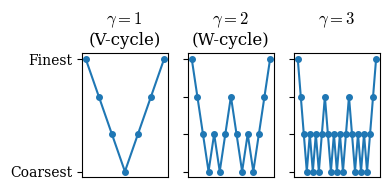

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(4, 2))
ax[0].plot(*generate_multigrid_cycle_data(1, 4), marker="o")
ax[1].plot(*generate_multigrid_cycle_data(2, 4), marker="o")
ax[2].plot(*generate_multigrid_cycle_data(3, 4), marker="o")

for a in ax:
    a.set_xticks([])
    a.set_yticklabels([])
ax[0].set_yticks([1, 4])
ax[0].set_yticklabels(["Coarsest", "Finest"])
ax[0].set_title("$\\gamma=1$ \n(V-cycle)", fontsize=12)
ax[1].set_title("$\\gamma=2$ \n(W-cycle)", fontsize=12)
ax[2].set_title("$\\gamma=3$ \n", fontsize=12)
fig.set_tight_layout(True)

In [5]:
fig.savefig("multigrid_cycles.png")
fig.savefig("multigrid_cycles.pdf")